<a href="https://colab.research.google.com/github/minjikim0330/ml/blob/main/07_intro_to_clustering_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 비지도 학습 - 고객 세분화 및 이상치 탐지 예시

데이터의 숨겨진 패턴을 찾는 비지도 학습 Preview
- 실생활 활용 예: 고객 세분화(맞춤형 마케팅), 이상 탐지(사기 거래 방지 등)
- 종류 : K-means, DBSCAN, Hierarchical Clustering 등

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. 고객 세분화 K-Means

- 가상의 고객 데이터
  - 구매 횟수, 총 지출액 생성
- 비슷한 소비 패턴을 가진 고객군으로 나누기
- K-Means: 사전에 그룹의 수 K를 지정하여 중심점 Centroid를 기준으로 데이터를 나눔

In [ ]:
# 1. Generate fake customer data (Purchase frequency vs. Total spending)
X_customers, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
X_customers

array([[ 8.36856841e-01,  2.13635938e+00],
       [-1.41365810e+00,  7.40962324e+00],
       [ 1.15521298e+00,  5.09961887e+00],
       [-1.01861632e+00,  7.81491465e+00],
       [ 1.27135141e+00,  1.89254207e+00],
       [ 3.43761754e+00,  2.61654166e-01],
       [-1.80822253e+00,  1.59701749e+00],
       [ 1.41372442e+00,  4.38117707e+00],
       [-2.04932168e-01,  8.43209665e+00],
       [-7.11099611e-01,  8.66043846e+00],
       [-1.71237268e+00,  2.77780226e+00],
       [-2.67000792e+00,  8.35389140e+00],
       [ 1.24258802e+00,  4.50399192e+00],
       [-2.22783649e+00,  6.89479938e+00],
       [ 1.45513831e+00, -2.91989981e-02],
       [ 4.53791789e-01,  3.95647753e+00],
       [ 1.06923853e+00,  4.53068484e+00],
       [ 2.56936589e+00,  5.07048304e-01],
       [-1.06690610e+00,  3.13165795e+00],
       [-1.07859101e+00,  2.20451529e+00],
       [ 2.71506328e+00,  1.29082190e+00],
       [ 1.77710994e+00,  1.18655254e+00],
       [ 7.34363910e-01,  5.03725437e+00],
       [-1.

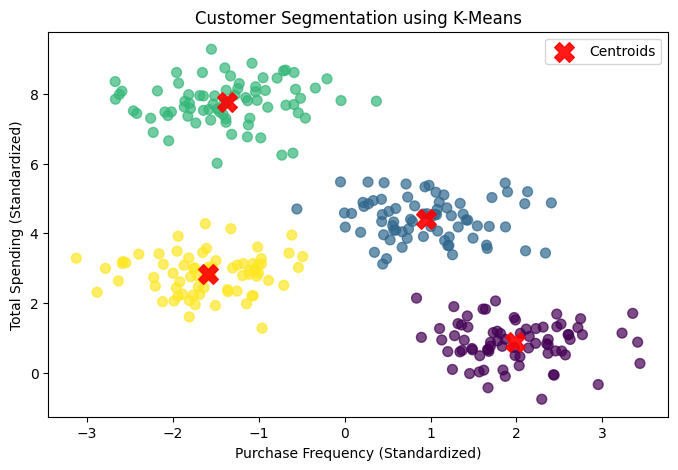

In [ ]:
# 2. Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_customers)

# 3. Visualize the results
plt.figure(figsize=(8, 5))
plt.scatter(X_customers[:, 0], X_customers[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.7)

# Plot the centroids (Cluster centers)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Centroids')

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Purchase Frequency (Standardized)")
plt.ylabel("Total Spending (Standardized)")
plt.legend()
plt.show()

## 2. 복잡한 형태의 군집 & 이상치 탐지 DBSCAN

- 데이터가 둥근 형태가 아닐 때 K-Means의 한계 존재
- DBSCAN: 밀도를 기반으로 군집화
- 장점: 그룹의 수 K를 미리 정할 필요 없음
- 밀도가 낮은 곳에 있는 데이터는 이상치로 판별

In [ ]:
# 1. Generate moon-shaped data to show K-Means limitations and DBSCAN strengths
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=0)
X_moons

array([[ 0.81680544,  0.5216447 ],
       [ 1.61859642, -0.37982927],
       [-0.02126953,  0.27372826],
       [-1.02181041, -0.07543984],
       [ 1.76654633, -0.17069874],
       [ 1.8820287 , -0.04238449],
       [ 0.97481551,  0.20999374],
       [ 0.88798782, -0.48936735],
       [ 0.89865156,  0.36637762],
       [ 1.11638974, -0.53460385],
       [-0.36380036,  0.82790185],
       [ 0.24702417, -0.23856676],
       [ 1.81658658, -0.13088387],
       [ 1.2163905 , -0.40685761],
       [-0.8236696 ,  0.64235178],
       [ 0.98065583,  0.20850838],
       [ 0.54097175,  0.88616823],
       [ 0.348031  , -0.30101351],
       [ 0.35181497,  0.88827765],
       [-0.77708642,  0.82253872],
       [ 1.92590813,  0.01214146],
       [ 0.86096723, -0.47653216],
       [ 0.19990695,  0.99672359],
       [ 1.2895301 , -0.37071087],
       [-0.27847636,  1.02538452],
       [ 0.24187916, -0.07627812],
       [ 1.84988768, -0.09773674],
       [ 1.88406869,  0.0449402 ],
       [ 0.165822  ,

- `엡실론` :  주변 이웃을 탐색할 거리
  - ex) 특정 데이터 포인트에서 반경 0.3 안에 다른 점들이 있는지 확인

- `min_samples=5` : 하나의 그룹으로 인정받기 위해 반경(eps) 안에 있어야 하는 최소 이웃의 수

  - ex) 반경 0.3 안에 자기 자신 포함 5개 이상의 점이 모여 있어야 하나의 군집 시작

- 군집 방식 : 각 데이터에 `0`, `1`, `2` 같은 소속 군집 번호 부여
- 이상치 판단 : 반경 안에 이웃 부족 or 다른 군집 근처에 없는 점들에 `-1` 레이블 부여

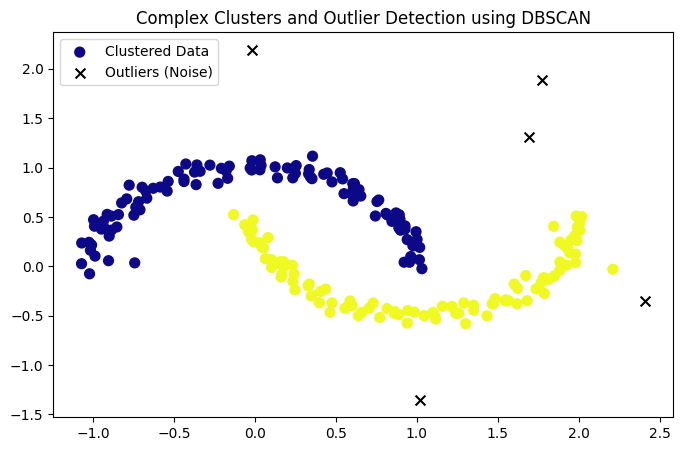

In [ ]:
# Add some random outliers (anomalies)
outliers = np.random.uniform(low=-1.5, high=2.5, size=(10, 2))
X_mixed = np.vstack([X_moons, outliers])

# 2. Apply DBSCAN
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_mixed)

# 3. Visualize DBSCAN results
plt.figure(figsize=(8, 5))

# Core points & edge points (assigned to a cluster)
plt.scatter(X_mixed[dbscan_labels >= 0, 0], X_mixed[dbscan_labels >= 0, 1],
            c=dbscan_labels[dbscan_labels >= 0], cmap='plasma', s=50, label='Clustered Data')

# Noise points (Anomalies, label is -1)
plt.scatter(X_mixed[dbscan_labels == -1, 0], X_mixed[dbscan_labels == -1, 1],
            c='black', s=50, marker='x', label='Outliers (Noise)')

plt.title("Complex Clusters and Outlier Detection using DBSCAN")
plt.legend()
plt.show()

## 3. 데이터의 계층 구조 파악 : Hierarchical Clustering

- 비슷한 데이터끼리 묶고 그 그룹들을 다시 묶어 나가는 방식
- 트리 구조인 덴드로그램을 통해 시각적으로 데이터의 관계 파악 가능
- 어디서 자르느냐에 따라 군집의 개수 조절 가능
- 이 가로선이 트리의 세로 기둥들과 만나는 횟수가 곧 최종 군집의 개수

In [ ]:
# 1. Generate a small dataset for clear visualization
X_hier, _ = make_blobs(n_samples=20, centers=3, random_state=42)
X_hier

array([[-2.97867201,  9.55684617],
       [-4.23411546,  8.4519986 ],
       [-3.52202874,  9.32853346],
       [-2.26723535,  7.10100588],
       [ 3.48888526,  2.3488677 ],
       [-8.20781324, -6.68324836],
       [-2.97261532,  8.54855637],
       [ 4.62638161,  0.91545875],
       [ 4.09549611,  2.08409227],
       [ 4.03924015,  1.68147593],
       [-6.6707636 , -8.83977972],
       [ 6.10552761,  1.74739338],
       [-6.14116061, -6.70874131],
       [-3.4172217 ,  7.60198243],
       [-6.99527547, -7.18121329],
       [-0.92998481,  9.78172086],
       [-8.35814918, -7.5999538 ],
       [-6.05708228, -8.10095324],
       [ 4.70740704,  0.5484215 ],
       [ 4.03817222,  3.82544787]])

- `linkage` : 데이터 점들 간의 거리를 계산하여 묶어나가는 규칙 정의
- `ward` : 두 그룹을 묶었을 때 그룹 내 데이터들이 얼마나 퍼져있는지 즉 분산이 가장 적게 증가하는 쪽으로 영리하게 묶는 방법
- y : 두 그룹을 합칠 때 그룹 간의 거리

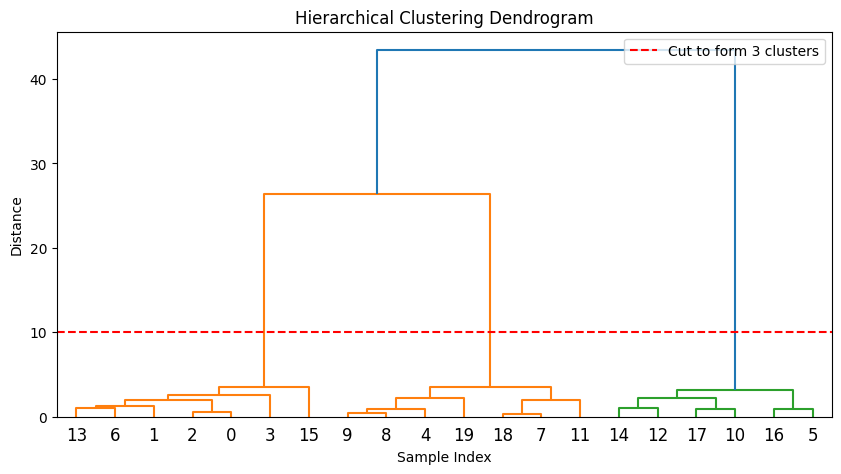

In [ ]:
# 2. Perform hierarchical clustering and plot the dendrogram
plt.figure(figsize=(10, 5))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

# Calculate the linkage matrix (Ward's method minimizes variance within clusters)
linked = linkage(X_hier, method='ward')

# Draw the dendrogram
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)

plt.axhline(y=10, color='r', linestyle='--', label='Cut to form 3 clusters')
plt.legend()
plt.show()

## 문제

데이터가 몇 개의 그룹으로 나뉘는지 미리 알 수 없고, 데이터 안에 이상치가 섞여 있는 상황이라면

K-means와 DBSCAN 중 어떤 알고리즘이 더 유리할까? 그 이유는?

- DBSCAN이 더 유리하다.

K-means는 군집 수(k)를 미리 정해야 하고 이상치에 영향을 많이 받는다.
반면 DBSCAN은 밀도 기반 방법으로 군집 수를 사전에 알 필요가 없다.
또한 데이터의 이상치를 noise로 분리할 수 있어 안정적인 군집 형성이 가능하다.